# Modelado


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

## Cargar datos

In [2]:
df = pd.read_csv("../data/processed/olist_engineering.csv")
olist_scaled = joblib.load("../data/processed/olist_scaled.pkl")
category_map = joblib.load("../models/category_map.pkl")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       115878 non-null  str    
 1   customer_id                    115878 non-null  str    
 2   order_purchase_timestamp       115878 non-null  str    
 3   customer_unique_id             115878 non-null  str    
 4   order_item_id                  115878 non-null  float64
 5   product_category_name_english  115878 non-null  str    
 6   payment_value                  115878 non-null  float64
 7   product_category_number        115878 non-null  int64  
 8   month                          115878 non-null  int64  
 9   day_of_week                    115878 non-null  int64  
 10  hour                           115878 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 9.7 MB


### KMeans Clustering

In [3]:
model_kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)

#Creo una variable para los diferentes clusters
df["customer_type"] = model_kmeans.fit_predict(olist_scaled)

c:\Users\Usuario\miniconda3\envs\env_commerce_py313\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [ ]:
df_customer_profile = df.groupby("customer_type")[[,"month", "day_of_week", "hour"]].mean()
df_customer_profile['customers_count'] = df['customer_type'].value_counts()
df_customer_profile

,month,day_of_week,hour,customers_count
customer_type,,,,
0,6.145173,2.553206,14.391473,2838
1,4.386794,0.900967,15.076911,38876
2,4.292574,4.528517,14.957458,39467
3,9.847998,2.799176,14.223535,34697


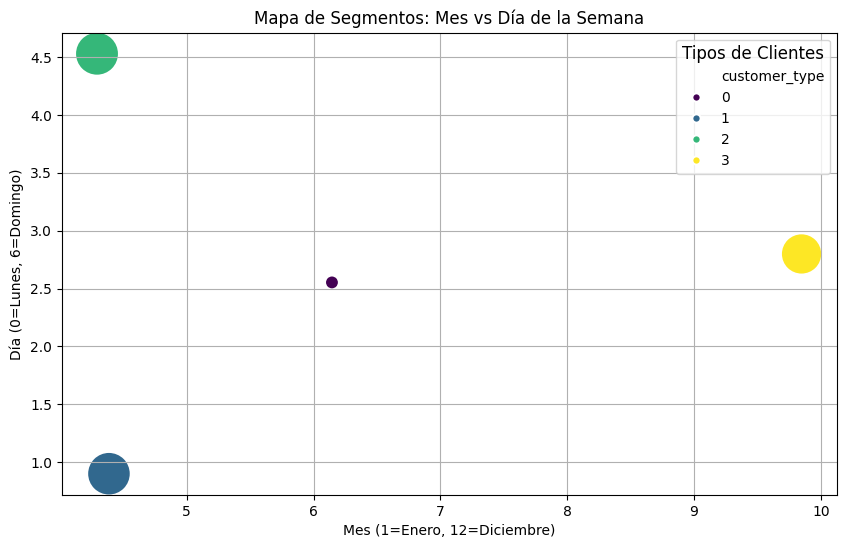

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_customer_profile, x='month', y='day_of_week', size='customers_count', hue="customer_type", palette='viridis', sizes=(100, 1000), legend="full")
plt.title('Mapa de Segmentos: Mes vs Día de la Semana')
plt.xlabel('Mes (1=Enero, 12=Diciembre)')
plt.ylabel('Día (0=Lunes, 6=Domingo)')
plt.grid(True)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:5], labels[0:5], title='Tipos de Clientes', title_fontsize='12', loc='upper right')

#### Observaciones:
> - La grafica presenta una distribucion de clusters bien diferenciada, indica que el número de clusters en los que se ha agrupado a los clientes es el correcto.
> - El primero grupo, `cluster 0`, representa a los clientes que efectuan compras sobre el mes de abril los jueves.
> - El Grupo minoritario en azul `cluster 1`, representa los clientes que suelen hacer compras en junio los martes.
> - `El cluster 2` en verde, representa los clientes que realizan compras a finales de septiembre los martes.
> - Por último el `cluster 3` representa los clientes que realizan compras a principio de abril los lunes.

CATEGORIA TOP


In [6]:
# Agrupar por cluster y se calcúla estadísticas clave
df_strategic_profile = df.groupby("customer_type").agg(
    spending_avg=("payment_value","mean"),
    spending_median=("payment_value","median"),
    spending_std_dev=("payment_value","std"),
    mont_avg=("month","mean"),
    day_of_week_avg=("day_of_week", "mean"),
    hour_avg=("hour","mean"),
    product_category_top_number=("product_category_number", lambda x: x.mode()[0])
).reset_index()

# Mapeo del número de la categoría con el nombre.
df_strategic_profile["product_category_top_name"] = df_strategic_profile["product_category_top_number"].map(category_map)
df_strategic_profile

,customer_type,spending_avg,spending_median,spending_std_dev,mont_avg,day_of_week_avg,hour_avg,product_category_top_number,product_category_top_name
0,0,1349.093710,1086.76,939.114933,6.145173,2.553206,14.391473,8,computers_accessories
1,1,143.871611,105.74,126.872252,4.386794,0.900967,15.076911,9,bed_bath_table
2,2,143.046287,106.50,125.126113,4.292574,4.528517,14.957458,9,bed_bath_table
3,3,143.566718,105.06,127.040570,9.847998,2.799176,14.223535,9,bed_bath_table


COMPRA MAS RECURRENTE POR CLUSTER


In [7]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_category_name_english',
       'payment_value', 'product_category_number', 'month', 'day_of_week',
       'hour', 'customer_type'],
      dtype='str')

In [8]:
df_categorytop_per_cluster = df.groupby(["customer_type", "product_category_name_english"]).size().reset_index(name="count")
df_categorytop_per_cluster

,customer_type,product_category_name_english,count
0,0,agro_industry_and_commerce,35
1,0,air_conditioning,24
2,0,art,1
3,0,audio,1
4,0,auto,147
...,...,...,...
259,3,stationery,818
260,3,tablets_printing_image,21
261,3,telephony,1425
262,3,toys,1873


In [9]:
df_categorytop_per_cluster = df_categorytop_per_cluster.sort_values(["customer_type", "count"], ascending=[True, False])

In [10]:
df_categorytop_per_cluster = df_categorytop_per_cluster.groupby('customer_type').head(3)
df_categorytop_per_cluster

,customer_type,product_category_name_english,count
12,0,computers_accessories,311
52,0,watches_gifts,265
29,0,health_beauty,201
60,1,bed_bath_table,4024
96,1,health_beauty,3493
117,1,sports_leisure,3098
130,2,bed_bath_table,4070
166,2,health_beauty,3534
162,2,furniture_decor,3132
201,3,bed_bath_table,3643


#### Observaciones:
> - El tipo de cliente (0) tiene un gasto promedio de 161.95R$, una media de 107.80R$ y una desviacion estandar de 199.45R$, del cual la categoria top de compra es `bed_table_table`.
> - El tipo de cliente (1) tiene un gasto promedio de 287.08R$, una media de 116.36R$ y una desviacion estandar de 650.61R$, del cual la categoria top de compra es `consoles_games`.
> - El tipo de cliente (2) tiene un gasto promedio de 163.73R$, una media de 107.11R$ y una desviacion estandar de 202.40R$, del cual la categoria top de compra es `bed_table_table`.
> - El tipo de cliente (3) tiene un gasto promedio de 163.15R$, una media de 108.11R$ y una desviacion estandar de 194. 52R$, del cual la categoria top de compra es `bed_table_table`.

## Guardar datos

In [11]:
df.to_csv("../data/processed/olist_segmented_customers.csv", index=False)